In [106]:
import torch
import nibabel as nib
import numpy as np
import sys
import glob
from natsort import natsorted

# import matplotlib.pyplot as plt
sys.path.append("../src")
from segment2d import *
from omegaconf import DictConfig, OmegaConf
import hydra

# import matplotlib.pyplot as plt
import json
from scipy.stats import pearsonr
from scipy.stats import mode
import os

LV_BLOOD_POOL_ID = 2
LV_LABEL = 2


def create_3d_blocks(data, num_blocks):
    """Simplified 3D block creation splitting CINE sequence into phases."""
    total_slices = data.shape[2]
    if total_slices < num_blocks:
        return None

    slices_per_block = total_slices // num_blocks
    if slices_per_block == 0:
        return None

    blocks = []
    for block_idx in range(num_blocks):
        slice_indices = [block_idx + i * num_blocks for i in range(slices_per_block)]

        if len(slice_indices) > 10:
            effective_indices = slice_indices[1:-1]
        else:
            effective_indices = slice_indices

        blocks.append(data[:, :, effective_indices])

    return blocks


def calculate_cine_sa_metrics_internal(pred_data, spacing, slice_num):
    """Calculates LV volumes and EF from a SAX CINE mask."""
    try:

        # pred_data = image.get_fdata()
        # spacing = spacing.header.get_zooms()

        blocks = create_3d_blocks(pred_data, slice_num)
        if not blocks:
            return None

        # Determine target number of slices with LV via mode
        valid_z_lengths = []
        for block in blocks:
            has_lv = np.any(block == LV_BLOOD_POOL_ID, axis=(0, 1))
            count = np.sum(has_lv)
            if count > 0:
                valid_z_lengths.append(count)

        if not valid_z_lengths:
            return None

        target_z_length = mode(valid_z_lengths, keepdims=False).mode

        block_volumes = []
        for i, block in enumerate(blocks):
            has_lv = np.any(block == LV_BLOOD_POOL_ID, axis=(0, 1))
            valid_z_indices = np.where(has_lv)[0]

            if len(valid_z_indices) != target_z_length:
                continue

            # Volume calculation with spacing correction
            lv_voxels = np.sum(block[..., valid_z_indices] == LV_BLOOD_POOL_ID)
            lv_vol = lv_voxels * spacing[0] * spacing[1] * spacing[2] / 1000.0
            block_volumes.append(lv_vol)
        #     print(
        #     f"Phase {i}: volume={lv_vol:.2f}, "
        #     f"valid_z={len(valid_z_indices)}, "
        #     f"indices={valid_z_indices}"
        # )

        if not block_volumes:
            return None

        # block_volumes.sort()
        # print(f"Sorted LV volumes: {block_volumes}")
        es_lv_vol, ed_lv_vol = robust_es_ed_from_volumes(block_volumes, k=2)
        # es_lv_vol, ed_lv_vol = robust_es_ed_percentile(block_volumes, low_percentile=1, high_percentile=99)
        # es_lv_vol = block_volumes[0]  # Min volume
        # ed_lv_vol = block_volumes[-1]  # Max volume
        lv_ef = ((ed_lv_vol - es_lv_vol) / ed_lv_vol * 100) if ed_lv_vol > 0 else 0

        return {"LV_EF": lv_ef}
    except Exception as e:
        print(f"Error in calculate_cine_sa_metrics_internal: {e}")
        return None


INPUT_DIR = "../input"
def robust_es_ed_percentile(block_volumes, low_percentile=2, high_percentile=98):
    vols = np.asarray(block_volumes, dtype=float)
    vols = vols[vols > 0]

    if len(vols) == 0:
        return None, None

    es_lv_vol = np.percentile(vols, low_percentile)
    ed_lv_vol = np.percentile(vols, high_percentile)

    return es_lv_vol, ed_lv_vol


def robust_es_ed_from_volumes(block_volumes, k=2):
    """
    Robustly estimate ES and ED volumes from phase volumes.

    k=1 means original min/max.
    k=2 means average 2 smallest and 2 largest.
    k=3 means average 3 smallest and 3 largest.
    """

    vols = np.asarray(block_volumes, dtype=float)
    vols = vols[vols > 0]

    if len(vols) == 0:
        return None, None

    vols = np.sort(vols)

    k = min(k, len(vols))

    es_lv_vol = np.mean(vols[:k])
    ed_lv_vol = np.mean(vols[-k:])

    return es_lv_vol, ed_lv_vol


def read_id_slice_sax():
    mapping_candidates = [
        os.path.join(INPUT_DIR, "CMR-MULTI", "CINE_MULTI", "id_slice_info_valid.json"),
        os.path.join(INPUT_DIR, "CMR-MULTI", "CINE_MULTI", "sax_slice_info_test.json"),
        os.path.join(INPUT_DIR, "CMR-MULTI", "CINE_MULTI", "sax_slice_info_valid.json"),
    ]
    mapping_path = next((path for path in mapping_candidates if os.path.exists(path)), None)
    if mapping_path is None:
        print(f"Warning: no SAX slice info JSON found under {os.path.join(INPUT_DIR, 'CMR-MULTI', 'CINE_MULTI')}.")
        return {}
    with open(mapping_path, "r") as f:
        id_slice = json.load(f)
    return id_slice

In [ ]:
{
    "CINE_SAX_121": 51.69263207215648,
    "CINE_SAX_122": 64.36976465895492,
    "CINE_SAX_123": 46.25349912115097,
    "CINE_SAX_124": 62.853420195439725,
    "CINE_SAX_125": 41.776710684273716,
    "CINE_SAX_126": 40.82234290147401,
    "CINE_SAX_127": 47.66158696794536,
    "CINE_SAX_128": 31.899800487696734,
    "CINE_SAX_129": 48.605075003504844,
    "CINE_SAX_130": 29.58734689023665,
    "CINE_SAX_131": 56.6079295154185,
    "CINE_SAX_132": 38.34827144686301,
    "CINE_SAX_133": 57.04012112036337,
    "CINE_SAX_134": 44.06990443775363,
    "CINE_SAX_135": 53.999142734676376,
    "CINE_SAX_136": 26.46955297430483,
    "CINE_SAX_137": 34.43029779887785,
    "CINE_SAX_138": 43.32525550521546,
    "CINE_SAX_139": 38.89573576534386,
    "CINE_SAX_140": 46.80990436263593,
    "CINE_SAX_141": 44.18145956607494,
    "CINE_SAX_142": 50.70277138092592,
    "CINE_SAX_143": 49.820948970456584,
    "CINE_SAX_144": 31.52843172763491,
    "CINE_SAX_145": 53.959873284054915,
    "CINE_SAX_146": 29.575280362681944,
    "CINE_SAX_147": 56.11093863189485,
    "CINE_SAX_148": 36.77318784099767,
    "CINE_SAX_149": 39.269716302429764,
    "CINE_SAX_150": 37.13505207444085
}

In [107]:
# read json files
with open("/home/nhattm/CMRSEG_Challange/ef_predictions_gt.json", "r") as f:
    ef_prediction_gt = json.load(f)
with open("/home/nhattm/CMRSEG_Challange/output_valvs1/task1_cine/ef_predictions.json", "r") as f:
    ef_prediction = json.load(f)
ef_gt = [ef_prediction_gt[key] for key in ef_prediction_gt.keys()]
ef_pred = [ef_prediction[key] for key in ef_prediction.keys()]

pearsonr(ef_gt, ef_pred)[0]

np.float64(0.8873664669127768)

In [108]:
pred_list = natsorted(glob.glob("../output_valvs1/task1_cine/SAX/*nii.gz"))
mask_list = natsorted(glob.glob("../input/CMR-MULTI/CINE_MULTI/SAX_VAL/anno/*.nii.gz"))
ef_pred = []
id_slice = read_id_slice_sax()
for pred_path in pred_list:
    pred = nib.load(pred_path)
    spacing = pred.header.get_zooms()
    id_patient = os.path.basename(pred_path).split(".")[0].split("_")[-1]
    id_patient = int(id_patient)
    id_patient = int(id_patient) + 105

    pred_post = pred.get_fdata().astype(np.uint8)

    # processed_pred = harmonize_lv_z_slices(pred_post, slice_num=id_slice[str(id_patient)], lv_label=LV_LABEL)
    ef_pred2 = calculate_cine_sa_metrics_internal(pred_post, spacing, slice_num=id_slice[str(id_patient)])["LV_EF"]

    # ef_pred.append(ef_pred2)
    ef_pred.append(ef_pred2)
    # break
print("personr:", pearsonr(ef_gt, ef_pred)[0])

personr: 0.8946148390186318


In [8]:
mask_path = "/home/nhattm/CMRSEG_Challange/input/CMR-MULTI/CINE_MULTI/SAX_TST/image/CINE_SAX_121.nii.gz"
pred = nib.load(mask_path).get_fdata()
header = nib.load(mask_path).header
# print(calculate_label3_mass(pred, header))

In [366]:
processed_mass = postprocess_scar_between_lv_myo_3d(
    pred,
    min_ratio=0.03,
    max_ratio=0.4,
    min_scar_voxels=50,
    min_component_voxels=2,
    myo_dilation_iter=4,
    lv_dilation_iter =4,
    max_reduce_fraction=0.1,
    
)
calculate_label3_mass(processed_mass, header)

np.float64(39.711462828370806)

In [370]:
# load json
import json
gt_mask_path = "/home/nhattm/CMR-MULTI/mass_predictions_gt.json"
mask_path = "/home/nhattm/CMR-MULTI/output/task2_lge/mass_predictions.json"
#load json files
with open(gt_mask_path, 'r') as f:
    gt_data = json.load(f)
with open(mask_path, 'r') as f:
    pred_data = json.load(f)
# calculate peason correlation coefficient
from scipy.stats import pearsonr
gt_masses = []
pred_masses = []
for patient in gt_data:
    gt_masses.append(gt_data[patient])
    pred_masses.append(pred_data[patient])
pearson_corr, _ = pearsonr(gt_masses, pred_masses)
print(f"Pearson correlation coefficient: {pearson_corr:.4f}")

Pearson correlation coefficient: 0.6869


In [145]:
mask = (
    nib.load("/home/nhattm/CMR-MULTI/input/CMR-MULTI/CINE_MULTI/SAX_VAL/anno/CINE_SAX_109.nii.gz")
    .get_fdata()
    .astype(np.uint8)
)

In [147]:
# calculate dice score between pred and mask
def dice_score(pred, mask, class_id=1):
    pred_class = (pred == class_id).astype(np.uint8)
    mask_class = (mask == class_id).astype(np.uint8)
    intersection = np.sum(pred_class * mask_class)
    union = np.sum(pred_class) + np.sum(mask_class)
    if union == 0:
        return 1.0  # Both pred and mask are empty
    return 2.0 * intersection / union
print(f"Dice Score: {dice_score(pred, mask, class_id=1)}")
print(f"Dice Score: {dice_score(pred, mask, class_id=2)}")
print(f"Dice Score: {dice_score(pred, mask, class_id=3)}")



Dice Score: 0.8677243471136961
Dice Score: 0.9128731265327638
Dice Score: 0.9122117175551326


In [4]:
image = nib.load(image_path)
image = image.get_fdata()
mask = nib.load(image_path.replace("image", "anno"))
mask = mask.get_fdata()

(np.float64(-0.5), np.float64(154.5), np.float64(168.5), np.float64(-0.5))

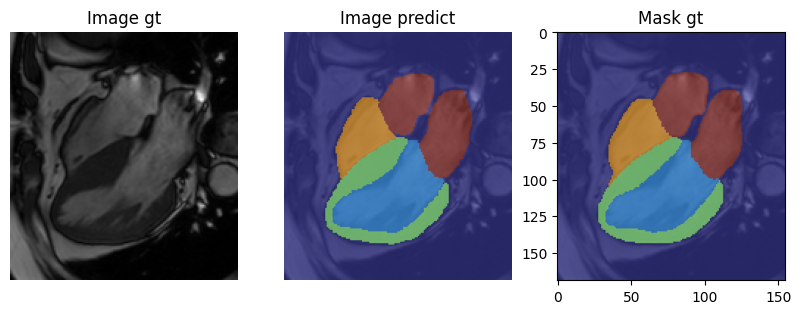

In [7]:
z = 50
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
ax[0].imshow(image[..., z], cmap="gray")
ax[0].set_title("Image gt")
# ax[0].imshow(mask[..., z], cmap="jet", alpha=0.3)
ax[1].imshow(image[..., z], cmap="gray", alpha=0.7)
ax[1].set_title("Image predict")
ax[1].imshow(mask[..., z], cmap="jet", alpha=0.5, vmin=0, vmax=4)

ax[2].imshow(image[..., z], cmap="gray", alpha=0.7)
ax[2].imshow(invert_seg[..., z], cmap="jet", alpha=0.5, vmin=0, vmax=4)
ax[2].set_title("Mask gt")
# off the axis
ax[0].axis('off')
ax[1].axis('off')


In [ ]:
def plot_image_mask_z(image, mask, padded_image, padded_mask, z):
    fig, ax = plt.subplots(1, 3, figsize=(10, 5))
    ax[0].imshow(image[..., z], cmap="gray")
    ax[0].set_title("Image gt")
    # ax[0].imshow(mask[..., z], cmap="jet", alpha=0.3)
    ax[1].imshow(padded_image[..., z], cmap="gray", alpha=0.7)
    ax[1].set_title("Image predict")
    ax[1].imshow(padded_mask[..., z], cmap="jet", alpha=0.5, vmin=0, vmax=4)

    ax[2].imshow(`padded_image`[..., z], cmap="gray", alpha=0.7)
    ax[2].imshow(mask[..., z], cmap="jet", alpha=0.5)
    ax[2].set_title("Mask gt")
    # off the axis
    ax[0].axis('off')
    ax[1].axis('off')


interact(lambda z: plot_image_mask_z(image, mask, image, invert_seg, z), z=(0, image.shape[-1] - 1))

## plot

In [4]:
from pathlib import Path
from natsort import natsorted
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns

root = Path('/home/nhattm/CMRSEG_Challange')
pred_root = root / 'output_val'
gt_root = root / 'input' / 'CMR-MULTI'
out_dir = pred_root / 'eval'
out_dir.mkdir(parents=True, exist_ok=True)

# Mapping: prediction folders -> validation annotation folders
pairs = [
    ('CINE', '2CH', pred_root / 'task1_cine' / '2CH', gt_root / 'CINE_MULTI' / '2CH_VAL' / 'anno'),
    ('CINE', '4CH', pred_root / 'task1_cine' / '4CH', gt_root / 'CINE_MULTI' / '4CH_VAL' / 'anno'),
    ('CINE', 'SAX', pred_root / 'task1_cine' / 'SAX', gt_root / 'CINE_MULTI' / 'SAX_VAL' / 'anno'),
    ('LGE', '2CH', pred_root / 'task2_lge' / '2CH', gt_root / 'LGE_MULTI' / '2CH_VAL' / 'anno'),
    ('LGE', '4CH', pred_root / 'task2_lge' / '4CH', gt_root / 'LGE_MULTI' / '4CH_VAL' / 'anno'),
    ('LGE', 'RAS', pred_root / 'task2_lge' / 'RAS', gt_root / 'LGE_MULTI' / 'RAS_VAL' / 'anno'),
    ('LGE', 'SAX', pred_root / 'task2_lge' / 'SAX', gt_root / 'LGE_MULTI' / 'SAX_VAL' / 'anno'),
]


def multiclass_dice_no_bg(pred: np.ndarray, gt: np.ndarray, eps: float = 1e-8) -> float:
    pred = pred.astype(np.int32)
    gt = gt.astype(np.int32)
    classes = sorted(set(np.unique(pred)).union(set(np.unique(gt))))
    classes = [c for c in classes if c != 0]
    if not classes:
        return 1.0

    dices = []
    for c in classes:
        p = pred == c
        g = gt == c
        inter = np.logical_and(p, g).sum(dtype=np.float64)
        denom = p.sum(dtype=np.float64) + g.sum(dtype=np.float64)
        if denom == 0:
            dices.append(1.0)
        else:
            dices.append((2.0 * inter + eps) / (denom + eps))
    return float(np.mean(dices))


rows = []

for cmr_type, view, pred_dir, gt_dir in pairs:
    pred_files = natsorted(pred_dir.glob('*.nii.gz'))
    gt_files = natsorted(gt_dir.glob('*.nii.gz'))

    if len(pred_files) != len(gt_files):
        raise ValueError(
            f'Count mismatch for {cmr_type}-{view}: pred={len(pred_files)}, gt={len(gt_files)}'
        )

    for pred_path, gt_path in zip(pred_files, gt_files):
        pred = nib.load(str(pred_path)).get_fdata()
        gt = nib.load(str(gt_path)).get_fdata()

        if pred.shape != gt.shape:
            raise ValueError(
                f'Shape mismatch: {pred_path.name} {pred.shape} vs {gt_path.name} {gt.shape}'
            )

        dice = multiclass_dice_no_bg(pred, gt)
        rows.append(
            {
                'type': cmr_type,
                'view': view,
                'pred_file': pred_path.name,
                'gt_file': gt_path.name,
                'dice': dice,
            }
        )

results = pd.DataFrame(rows)
results.to_csv(out_dir / 'dice_per_case.csv', index=False)

summary = (
    results.groupby(['type', 'view'], as_index=False)
    .agg(
        n=('dice', 'count'),
        mean_dice=('dice', 'mean'),
        median_dice=('dice', 'median'),
        std_dice=('dice', 'std'),
        min_dice=('dice', 'min'),
        max_dice=('dice', 'max'),
    )
)
summary.to_csv(out_dir / 'dice_summary_by_type_view.csv', index=False)

sns.set_theme(style='whitegrid')

for cmr_type, fig_name in [('CINE', 'boxplot_cine_dice.png'), ('LGE', 'boxplot_lge_dice.png')]:
    df = results[results['type'] == cmr_type].copy()
    view_order = list(df['view'].drop_duplicates())

    plt.figure(figsize=(8, 5), dpi=150)
    sns.boxplot(data=df, x='view', y='dice', order=view_order, color='#8fbcd4')
    sns.stripplot(data=df, x='view', y='dice', order=view_order, color='#1f4f66', alpha=0.6, size=4, jitter=0.2)
    plt.ylim(0.0, 1.0)
    plt.xlabel('View')
    plt.ylabel('Dice (mean over non-background classes)')
    plt.title(f'{cmr_type} Validation Dice by View')
    plt.tight_layout()
    plt.savefig(out_dir / fig_name)
    plt.close()

print('Saved:', out_dir / 'dice_per_case.csv')
print('Saved:', out_dir / 'dice_summary_by_type_view.csv')
print('Saved:', out_dir / 'boxplot_cine_dice.png')
print('Saved:', out_dir / 'boxplot_lge_dice.png')
print('\nSummary:')
print(summary.to_string(index=False))

Saved: /home/nhattm/CMRSEG_Challange/output_val/eval/dice_per_case.csv
Saved: /home/nhattm/CMRSEG_Challange/output_val/eval/dice_summary_by_type_view.csv
Saved: /home/nhattm/CMRSEG_Challange/output_val/eval/boxplot_cine_dice.png
Saved: /home/nhattm/CMRSEG_Challange/output_val/eval/boxplot_lge_dice.png

Summary:
type view  n  mean_dice  median_dice  std_dice  min_dice  max_dice
CINE  2CH 15   0.894870     0.902243  0.022578  0.841147  0.928625
CINE  4CH 15   0.909472     0.915732  0.022186  0.853764  0.943642
CINE  SAX 15   0.910700     0.916180  0.030015  0.839899  0.945925
 LGE  2CH  7   0.652644     0.663275  0.180626  0.430726  0.889466
 LGE  4CH  7   0.782552     0.805293  0.090351  0.622787  0.890764
 LGE  RAS 14   0.880473     0.925908  0.102318  0.656254  0.960424
 LGE  SAX  7   0.718230     0.688084  0.107078  0.579835  0.866169


In [63]:
# Class-wise Dice evaluation and one combined figure (CINE + LGE)
from pathlib import Path
from natsort import natsorted
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

root = Path('/home/nhattm/CMRSEG_Challange')
pred_root = root / 'output_val'
gt_root = root / 'input' / 'CMR-MULTI'
out_dir = pred_root / 'eval'
out_dir.mkdir(parents=True, exist_ok=True)

# Number of classes from config/data_config.yaml
num_classes_by_type_view = {
    ('CINE', '2CH'): 3,
    ('CINE', '4CH'): 6,
    ('CINE', 'SAX'): 4,
    ('LGE', '2CH'): 4,
    ('LGE', '4CH'): 5,
    ('LGE', 'RAS'): 2,
    ('LGE', 'SAX'): 5,
}

# True label definitions from dataset README (exclude class 0 background)
label_name_by_type_view = {
    ('CINE', 'SAX'): {
        1: 'Left Ventricle Myocardium',
        2: 'Left Ventricle Cavity',
        3: 'Right Ventricle Cavity',
    },
    ('CINE', '2CH'): {
        1: 'Left Ventricle Cavity',
        2: 'Left Ventricle Myocardium',
    },
    ('CINE', '4CH'): {
        1: 'Left Ventricle Cavity',
        2: 'Left Ventricle Myocardium',
        3: 'Right Ventricle Cavity',
        4: 'Right Atrium',
        5: 'Left Atrium',
    },
    ('LGE', 'SAX'): {
        1: 'Left Ventricle Cavity',
        2: 'Left Ventricle Myocardium',
        3: 'Myocardial Scar (Scar)',
        4: 'Right Ventricle Cavity',
    },
    ('LGE', '2CH'): {
        1: 'Left Ventricle Cavity',
        2: 'Left Ventricle Myocardium',
        3: 'Myocardial Scar (Scar)',
    },
    ('LGE', '4CH'): {
        1: 'Left Ventricle Cavity',
        2: 'Left Ventricle Myocardium',
        3: 'Myocardial Scar (Scar)',
        4: 'Right Ventricle Cavity',
    },
    ('LGE', 'RAS'): {
        1: 'Right Atrium',
    },
}

pairs = [
    ('CINE', '2CH', pred_root / 'task1_cine' / '2CH', gt_root / 'CINE_MULTI' / '2CH_VAL' / 'anno'),
    ('CINE', '4CH', pred_root / 'task1_cine' / '4CH', gt_root / 'CINE_MULTI' / '4CH_VAL' / 'anno'),
    ('CINE', 'SAX', pred_root / 'task1_cine' / 'SAX', gt_root / 'CINE_MULTI' / 'SAX_VAL' / 'anno'),
    ('LGE', '2CH', pred_root / 'task2_lge' / '2CH', gt_root / 'LGE_MULTI' / '2CH_VAL' / 'anno'),
    ('LGE', '4CH', pred_root / 'task2_lge' / '4CH', gt_root / 'LGE_MULTI' / '4CH_VAL' / 'anno'),
    ('LGE', 'RAS', pred_root / 'task2_lge' / 'RAS', gt_root / 'LGE_MULTI' / 'RAS_VAL' / 'anno'),
    ('LGE', 'SAX', pred_root / 'task2_lge' / 'SAX', gt_root / 'LGE_MULTI' / 'SAX_VAL' / 'anno'),
]


def dice_for_class(pred: np.ndarray, gt: np.ndarray, class_id: int, eps: float = 1e-8) -> float:
    pred_class = pred == class_id
    gt_class = gt == class_id
    inter = np.logical_and(pred_class, gt_class).sum(dtype=np.float64)
    denom = pred_class.sum(dtype=np.float64) + gt_class.sum(dtype=np.float64)
    if denom == 0:
        return 1.0
    return float((2.0 * inter + eps) / (denom + eps))


rows_class = []
for cmr_type, view, pred_dir, gt_dir in pairs:
    pred_files = natsorted(pred_dir.glob('*.nii.gz'))
    gt_files = natsorted(gt_dir.glob('*.nii.gz'))

    if len(pred_files) != len(gt_files):
        raise ValueError(
            f'Count mismatch for {cmr_type}-{view}: pred={len(pred_files)}, gt={len(gt_files)}'
        )

    num_classes = num_classes_by_type_view[(cmr_type, view)]
    class_ids = list(range(1, num_classes))  # exclude background class 0

    for pred_path, gt_path in zip(pred_files, gt_files):
        pred = nib.load(str(pred_path)).get_fdata().astype(np.int32)
        gt = nib.load(str(gt_path)).get_fdata().astype(np.int32)

        if pred.shape != gt.shape:
            raise ValueError(
                f'Shape mismatch: {pred_path.name} {pred.shape} vs {gt_path.name} {gt.shape}'
            )

        for class_id in class_ids:
            label_name = label_name_by_type_view[(cmr_type, view)].get(class_id, f'Class {class_id}')
            rows_class.append(
                {
                    "type": cmr_type,
                    "view": view,
                    "class_id": class_id,
                    "label_name": label_name,
                    "pred_file": pred_path.name,
                    "gt_file": gt_path.name,
                    "DSC": dice_for_class(pred, gt, class_id=class_id),
                }
            )

classwise = pd.DataFrame(rows_class)
classwise.to_csv(out_dir / 'dice_per_case_classwise.csv', index=False)

summary_classwise = (
    classwise.groupby(['type', 'view', 'class_id', 'label_name'], as_index=False)
    .agg(
        n=('DSC', 'count'),
        mean_dice=('DSC', 'mean'),
        median_dice=('DSC', 'median'),
        std_dice=('DSC', 'std'),
        min_dice=('DSC', 'min'),
        max_dice=('DSC', 'max'),
    )
)
summary_classwise.to_csv(out_dir / 'dice_summary_classwise.csv', index=False)

# Requested legend order and colors
legend_order = [
    'Left Ventricle Myocardium',
    'Left Ventricle Cavity',
    'Right Ventricle Cavity',
    'Right Atrium',
    'Left Atrium',
    'Myocardial Scar (Scar)',
]
color_map = {
    'Left Ventricle Myocardium': '#80ae80',  # green
    'Left Ventricle Cavity': '#f1d691',      # yellow
    'Right Ventricle Cavity': '#b17a65',     # brown
    'Right Atrium': '#6fb8d2',               # blue
    'Left Atrium': '#ff0000',                # red
    'Myocardial Scar (Scar)': '#800080',     # purple
}

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 1, figsize=(7, 10), dpi=1000, sharey=True)

for ax, cmr_type in zip(axes, ['CINE', 'LGE']):
    df = classwise[classwise['type'] == cmr_type].copy()
    view_order = list(df['view'].drop_duplicates())
    hue_order = [lbl for lbl in legend_order if lbl in set(df['label_name'])]

    sns.boxplot(
        data=df,
        x='view',
        y='DSC',
        hue='label_name',
        order=view_order,
        hue_order=hue_order,
        palette=color_map,
        showfliers=True,
        ax=ax,
    )
    sns.stripplot(
        data=df,
        x='view',
        y='DSC',
        hue='label_name',
        order=view_order,
        hue_order=hue_order,
        palette=color_map,
        dodge=True,
        alpha=0.28,
        size=2.0,
        linewidth=0,
        ax=ax,
    )

    if ax.get_legend() is not None:
        ax.get_legend().remove()

    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel('View')
    ax.set_ylabel('DSC')
    ax.set_title(f"DSC of {cmr_type} the CMR Challenge validation set", fontsize=12, fontweight='bold')

# One shared legend for both subplots
legend_handles = [Patch(facecolor=color_map[name], edgecolor='black', label=name) for name in legend_order]
fig.legend(
    handles=legend_handles,
    labels=legend_order,
    title='Anatomical Label',
    loc='lower center',
    ncol=3,
    bbox_to_anchor=(0.5, -0.015),
)

# fig.suptitle('Class-wise Dice Distribution (CINE + LGE)', fontsize=14, y=1.01)
plt.tight_layout(rect=[0, 0.06, 1, 0.98])
combined_fig = out_dir / 'boxplot_classwise_dice_combined.png'
plt.savefig(combined_fig)
# plt.close()

print('Saved:', out_dir / 'dice_per_case_classwise.csv')
print('Saved:', out_dir / 'dice_summary_classwise.csv')
print('Saved:', combined_fig)
print('\nClass-wise summary (mean dice):')
print(summary_classwise[['type', 'view', 'class_id', 'label_name', 'mean_dice']].to_string(index=False))

Saved: /home/nhattm/CMRSEG_Challange/output_val/eval/dice_per_case_classwise.csv
Saved: /home/nhattm/CMRSEG_Challange/output_val/eval/dice_summary_classwise.csv
Saved: /home/nhattm/CMRSEG_Challange/output_val/eval/boxplot_classwise_dice_combined.png

Class-wise summary (mean dice):
type view  class_id                label_name  mean_dice
CINE  2CH         1     Left Ventricle Cavity   0.923738
CINE  2CH         2 Left Ventricle Myocardium   0.866002
CINE  4CH         1     Left Ventricle Cavity   0.944895
CINE  4CH         2 Left Ventricle Myocardium   0.859423
CINE  4CH         3    Right Ventricle Cavity   0.908796
CINE  4CH         4              Right Atrium   0.903028
CINE  4CH         5               Left Atrium   0.931218
CINE  SAX         1 Left Ventricle Myocardium   0.906531
CINE  SAX         2     Left Ventricle Cavity   0.932136
CINE  SAX         3    Right Ventricle Cavity   0.893433
 LGE  2CH         1     Left Ventricle Cavity   0.877763
 LGE  2CH         2 Left Ventricl

In [56]:
import numpy as np
import pandas as pd
import nibabel as nib
from pathlib import Path
from natsort import natsorted
from scipy import stats

# LGE SAX: class 2 = Myocardium, class 3 = Myocardial Scar
root = Path('/home/nhattm/CMRSEG_Challange')
pred_dir = root / 'output_val' / 'task2_lge' / 'SAX'
gt_dir = root / 'input' / 'CMR-MULTI' / 'LGE_MULTI' / 'SAX_VAL' / 'anno'

pred_files = natsorted(pred_dir.glob('*.nii.gz'))
gt_files = natsorted(gt_dir.glob('*.nii.gz'))

if len(pred_files) != len(gt_files):
    raise ValueError(f'Count mismatch: pred={len(pred_files)}, gt={len(gt_files)}')

rows = []
for pred_path, gt_path in zip(pred_files, gt_files):
    pred_nii = nib.load(str(pred_path))
    gt_nii = nib.load(str(gt_path))

    pred = pred_nii.get_fdata().astype(np.int32)
    gt = gt_nii.get_fdata().astype(np.int32)

    if pred.shape != gt.shape:
        raise ValueError(
            f'Shape mismatch: {pred_path.name} {pred.shape} vs {gt_path.name} {gt.shape}'
        )

    pred_voxel_vol = np.prod(pred_nii.header.get_zooms()[:3])
    gt_voxel_vol = np.prod(gt_nii.header.get_zooms()[:3])

    pred_scar = float(np.sum(pred == 3) * pred_voxel_vol)
    pred_myo = float(np.sum(pred == 2) * pred_voxel_vol) + pred_scar  # Include scar in myocardium volume

    gt_scar = float(np.sum(gt == 3) * gt_voxel_vol) 
    gt_myo = float(np.sum(gt == 2) * gt_voxel_vol) + gt_scar  # Include scar in myocardium volume

    rows.append(
        {
            'pred_file': pred_path.name,
            'gt_file': gt_path.name,
            'Volume_Myocardium_GT': gt_myo,
            'Volume_Infarction_GT': gt_scar,
            'Volume_Myocardium_Pred': pred_myo,
            'Volume_Infarction_Pred': pred_scar,
        }
    )

vol_df = pd.DataFrame(rows)

# Keep names similar to your example
gt_volume = vol_df.rename(
    columns={
        'Volume_Myocardium_GT': 'Volume_Myocardium',
        'Volume_Infarction_GT': 'Volume_Infarction',
    }
)[['gt_file', 'Volume_Myocardium', 'Volume_Infarction']]

result_emidec = vol_df.rename(
    columns={
        'Volume_Myocardium_Pred': 'Volume_Myocardium',
        'Volume_Infarction_Pred': 'Volume_Infarction',
    }
)[['pred_file', 'Volume_Myocardium', 'Volume_Infarction']]

# Use paired cases where GT has scar and myocardium > 0
paired_mask = (gt_volume['Volume_Infarction'] != 0) & (gt_volume['Volume_Myocardium'] > 0)

if paired_mask.sum() == 0:
    raise ValueError('No valid LGE SAX cases with non-zero GT scar and positive myocardium volume.')

gt = gt_volume.loc[paired_mask, 'Volume_Infarction'].to_numpy() / gt_volume.loc[paired_mask, 'Volume_Myocardium'].to_numpy()
pred = result_emidec.loc[paired_mask, 'Volume_Infarction'].to_numpy() / result_emidec.loc[paired_mask, 'Volume_Myocardium'].replace(0, np.nan).to_numpy()

# Convert to numpy arrays
gt = np.array(gt)
pred = np.array(pred)

# Check same length
if len(gt) != len(pred):
    raise ValueError('Both volume arrays must have the same length for paired test.')

# Remove NaN values (Wilcoxon requires complete pairs)
valid_mask = ~(np.isnan(gt) | np.isnan(pred))
gt_clean = gt[valid_mask]
pred_clean = pred[valid_mask]

if len(gt_clean) < 10:
    print('Warning: Less than 10 valid pairs. Results may be unreliable.')

print(f'Number of valid pairs: {len(gt_clean)}')

# Perform Wilcoxon Signed-Rank Test
statistic, p_value = stats.wilcoxon(gt_clean, pred_clean)

# Output results
print('\nWilcoxon Signed-Rank Test results:')
print(f'Statistic: {statistic:.4f}')
print(f'p-value: {p_value:.4f}')

# Interpret significance
alpha = 0.05
if p_value < alpha:
    print('✅ Statistically significant difference (p < 0.05)')
else:
    print('❌ No statistically significant difference (p >= 0.05)')

# Additional statistics
differences = gt_clean - pred_clean
median_diff = np.median(differences)
mad = np.median(np.abs(differences - median_diff))  # Median Absolute Deviation

print('\nDescriptive statistics:')
print(f'Median difference (GT - Pred): {median_diff:.6f}')
print(f'MAD (Median Absolute Deviation): {mad:.6f}')
print(f'Mean difference: {np.mean(differences):.6f}')
print(f'Std difference: {np.std(differences, ddof=1):.6f}')

# Effect size (r = z / sqrt(N))
n = len(gt_clean)
z_stat = abs(stats.norm.ppf(max(p_value / 2, 1e-300)))  # Approximate z-score
effect_size_r = z_stat / np.sqrt(n)
print(f'Effect size (r): {effect_size_r:.3f}')
print('  - 0.1 = small, 0.3 = medium, 0.5 = large')

# Save per-case ratios for traceability
ratio_df = pd.DataFrame(
    {
        'gt_file': gt_volume.loc[paired_mask, 'gt_file'].to_numpy()[valid_mask],
        'pred_file': result_emidec.loc[paired_mask, 'pred_file'].to_numpy()[valid_mask],
        'scar_to_myo_gt': gt_clean,
        'scar_to_myo_pred': pred_clean,
        'difference_gt_minus_pred': gt_clean - pred_clean,
    }
)
ratio_csv = out_dir / 'lge_sax_scar_to_myo_ratio.csv'
ratio_df.to_csv(ratio_csv, index=False)
print(f'\nSaved: {ratio_csv}')

Number of valid pairs: 5

Wilcoxon Signed-Rank Test results:
Statistic: 7.0000
p-value: 1.0000
❌ No statistically significant difference (p >= 0.05)

Descriptive statistics:
Median difference (GT - Pred): 0.052288
MAD (Median Absolute Deviation): 0.199655
Mean difference: 0.006691
Std difference: 0.192470
Effect size (r): 0.000
  - 0.1 = small, 0.3 = medium, 0.5 = large

Saved: /home/nhattm/CMRSEG_Challange/output_val/eval/lge_sax_scar_to_myo_ratio.csv


In [97]:
import numpy as np
import pandas as pd
import nibabel as nib
from pathlib import Path
from natsort import natsorted
from medpy.metric.binary import dc, hd, assd
import json
from scipy.stats import pearsonr
root = Path('/home/nhattm/CMRSEG_Challange')
folder_output = root / 'output'
out_dir = folder_output / "eval"
out_dir.mkdir(parents=True, exist_ok=True)

# Task/view mapping for validation evaluation
pairs = [
    ('task1_cine', 'CINE', '2CH', folder_output / 'task1_cine' / '2CH', root / 'input' / 'CMR-MULTI' / 'CINE_MULTI' / '2CH_VAL' / 'anno', 3),
    ('task1_cine', 'CINE', '4CH', folder_output / 'task1_cine' / '4CH', root / 'input' / 'CMR-MULTI' / 'CINE_MULTI' / '4CH_VAL' / 'anno', 6),
    ('task1_cine', 'CINE', 'SAX', folder_output / 'task1_cine' / 'SAX', root / 'input' / 'CMR-MULTI' / 'CINE_MULTI' / 'SAX_VAL' / 'anno', 4),
    ('task2_lge', 'LGE', '2CH', folder_output / 'task2_lge' / '2CH', root / 'input' / 'CMR-MULTI' / 'LGE_MULTI' / '2CH_VAL' / 'anno', 4),
    ('task2_lge', 'LGE', '4CH', folder_output / 'task2_lge' / '4CH', root / 'input' / 'CMR-MULTI' / 'LGE_MULTI' / '4CH_VAL' / 'anno', 5),
    ('task2_lge', 'LGE', 'RAS', folder_output / 'task2_lge' / 'RAS', root / 'input' / 'CMR-MULTI' / 'LGE_MULTI' / 'RAS_VAL' / 'anno', 2),
    ('task2_lge', 'LGE', 'SAX', folder_output / 'task2_lge' / 'SAX', root / 'input' / 'CMR-MULTI' / 'LGE_MULTI' / 'SAX_VAL' / 'anno', 5),
]


def safe_binary_metrics(pred_bin: np.ndarray, gt_bin: np.ndarray, spacing):
    pred_has = bool(np.any(pred_bin))
    gt_has = bool(np.any(gt_bin))

    if (not pred_has) and (not gt_has):
        return 1.0, 0.0, 0.0
    if pred_has != gt_has:
        return 0.0, np.nan, np.nan

    dsc = float(dc(pred_bin, gt_bin))
    hd_val = float(hd(pred_bin, gt_bin, voxelspacing=spacing))
    asd_val = float(assd(pred_bin, gt_bin, voxelspacing=spacing))
    return dsc, hd_val, asd_val


rows = []
for task_name, task_type, view, pred_dir, gt_dir, num_classes in pairs:
    pred_files = natsorted(pred_dir.glob('*.nii.gz'))
    gt_files = natsorted(gt_dir.glob('*.nii.gz'))

    if len(pred_files) != len(gt_files):
        raise ValueError(
            f'Count mismatch for {task_name}-{view}: pred={len(pred_files)}, gt={len(gt_files)}'
        )

    class_ids = range(1, num_classes)  # exclude background 0
    for pred_path, gt_path in zip(pred_files, gt_files):
        pred_nii = nib.load(str(pred_path))
        gt_nii = nib.load(str(gt_path))
        pred = pred_nii.get_fdata().astype(np.int32)
        gt = gt_nii.get_fdata().astype(np.int32)

        if pred.shape != gt.shape:
            raise ValueError(
                f'Shape mismatch: {pred_path.name} {pred.shape} vs {gt_path.name} {gt.shape}'
            )

        spacing = tuple(float(v) for v in gt_nii.header.get_zooms()[:3])

        for class_id in class_ids:
            pred_bin = pred == class_id
            gt_bin = gt == class_id
            dsc, hd_val, asd_val = safe_binary_metrics(pred_bin, gt_bin, spacing)
            rows.append(
                {
                    'task': task_name,
                    'type': task_type,
                    'view': view,
                    'class_id': class_id,
                    'pred_file': pred_path.name,
                    'gt_file': gt_path.name,
                    'DSC': dsc,
                    'HD': hd_val,
                    'ASD': asd_val,
                }
            )

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv(out_dir / 'metrics_dsc_hd_asd_per_case_class.csv', index=False)

# Aggregates

def agg_mean(x):
    return float(np.nanmean(x))


def agg_std(x):
    return float(np.nanstd(x, ddof=1))


# Task-level aggregate (task1_cine, task2_lge)
summary_task = (
    metrics_df.groupby(['task'], as_index=False)
    .agg(
        n=('DSC', 'count'),
        DSC_mean=('DSC', agg_mean),
        DSC_std=('DSC', agg_std),
        HD_mean=('HD', agg_mean),
        HD_std=('HD', agg_std),
        ASD_mean=('ASD', agg_mean),
        ASD_std=('ASD', agg_std),
    )
)
summary_task.to_csv(out_dir / 'metrics_dsc_hd_asd_summary_task.csv', index=False)

# Type-level summary (CINE/LGE)
summary_type = (
    metrics_df.groupby(['type'], as_index=False)
    .agg(
        n=('DSC', 'count'),
        DSC_mean=('DSC', agg_mean),
        DSC_std=('DSC', agg_std),
        HD_mean=('HD', agg_mean),
        HD_std=('HD', agg_std),
        ASD_mean=('ASD', agg_mean),
        ASD_std=('ASD', agg_std),
    )
)
summary_type.to_csv(out_dir / 'metrics_dsc_hd_asd_summary_type.csv', index=False)

# Task + view summary (requested)
summary_task_view = (
    metrics_df.groupby(['task', 'view'], as_index=False)
    .agg(
        n=('DSC', 'count'),
        DSC_mean=('DSC', agg_mean),
        DSC_std=('DSC', agg_std),
        HD_mean=('HD', agg_mean),
        HD_std=('HD', agg_std),
        ASD_mean=('ASD', agg_mean),
        ASD_std=('ASD', agg_std),
    )
)
summary_task_view.to_csv(out_dir / 'metrics_dsc_hd_asd_summary_task_view.csv', index=False)

print('Saved:', out_dir / 'metrics_dsc_hd_asd_per_case_class.csv')
print('Saved:', out_dir / 'metrics_dsc_hd_asd_summary_task.csv')
print('Saved:', out_dir / 'metrics_dsc_hd_asd_summary_type.csv')
print('Saved:', out_dir / 'metrics_dsc_hd_asd_summary_task_view.csv')

#################################################################
# print('\nTask-level summary (mean +- std):')
# for _, r in summary_task.iterrows():
#     print(
#         f"{r['task']}: "
#         f"DSC={r['DSC_mean']:.2f} +- {r['DSC_std']:.2f}, "
#         f"HD={r['HD_mean']:.2f} +- {r['HD_std']:.2f}, "
#         f"ASD={r['ASD_mean']:.2f} +- {r['ASD_std']:.2f}"
#     )

# print('\nTask + view summary (mean +- std):')
# for _, r in summary_task_view.iterrows():
#     print(
#         f"{r['task']} ({r['view']}): "
#         f"DSC={r['DSC_mean']:.2f} +- {r['DSC_std']:.2f}, "
#         f"HD={r['HD_mean']:.2f} +- {r['HD_std']:.2f}, "
#         f"ASD={r['ASD_mean']:.2f} +- {r['ASD_std']:.2f}"
#     )
#################################################################
print("\nTask-level summary (mean +- std):")
for _, r in summary_task.iterrows():
    print(
        f"{r['task']}: "
        f"DSC={r['DSC_mean']:.4f} +- {r['DSC_std']:.4f}, "  
        f"HD={r['HD_mean']:.4f} +- {r['HD_std']:.4f}, "
        f"ASD={r['ASD_mean']:.4f} +- {r['ASD_std']:.4f}"
    )

print("\nTask + view summary (mean +- std):")
for _, r in summary_task_view.iterrows():
    print(
        f"{r['task']} ({r['view']}): "
        f"DSC={r['DSC_mean']:.4f} +- {r['DSC_std']:.4f}, "
        f"HD={r['HD_mean']:.4f} +- {r['HD_std']:.4f}, "
        f"ASD={r['ASD_mean']:.4f} +- {r['ASD_std']:.4f}"
    )

# Task 2 combined score: 0.7 * DSC + 0.3 * (0.5 * max(0, vPCC) + 0.5 * 1/(1 + RAE))
task2_row = summary_task.loc[summary_task['task'] == 'task2_lge']
if task2_row.empty:
    raise ValueError('task2_lge summary not found in summary_task')
task2_dsc = float(task2_row['DSC_mean'].iloc[0])

gt_mass_path = "/home/nhattm/CMRSEG_Challange/mass_predictions_gt.json"
pred_mass_path = folder_output / "task2_lge" / "mass_predictions.json"
with open(gt_mass_path, 'r') as f:
    gt_mass_data = json.load(f)
with open(pred_mass_path, 'r') as f:
    pred_mass_data = json.load(f)

common_patients = [patient for patient in gt_mass_data.keys() if patient in pred_mass_data]
if len(common_patients) == 0:
    raise ValueError('No overlapping patients found between ground-truth and prediction mass JSON files')

gt_masses = np.array([float(gt_mass_data[patient]) for patient in common_patients], dtype=float)
pred_masses = np.array([float(pred_mass_data[patient]) for patient in common_patients], dtype=float)

if len(common_patients) >= 2:
    try:
        vPCC = float(pearsonr(gt_masses, pred_masses)[0])
    except Exception:
        vPCC = 0.0
else:
    vPCC = 0.0

non_zero_gt_mask = gt_masses != 0
if not np.any(non_zero_gt_mask):
    raise ValueError('RAE cannot be computed because all ground-truth scar masses are zero')
rae = float(
    np.mean(
        np.abs(pred_masses[non_zero_gt_mask] - gt_masses[non_zero_gt_mask])
        / np.abs(gt_masses[non_zero_gt_mask])
    )
)

mass_term = 0.5 * max(0.0, vPCC) + 0.5 * (1.0 / (1.0 + rae))
task2_score = 0.7 * task2_dsc + 0.3 * mass_term

print('\nTask 2 score components:')
print(f'  DSC   = {task2_dsc:.4f}')
print(f'  vPCC  = {vPCC:.4f}')
print(f'  RAE   = {rae:.4f}')
print(f'  Score = {task2_score:.4f}')

Saved: /home/nhattm/CMRSEG_Challange/output/eval/metrics_dsc_hd_asd_per_case_class.csv
Saved: /home/nhattm/CMRSEG_Challange/output/eval/metrics_dsc_hd_asd_summary_task.csv
Saved: /home/nhattm/CMRSEG_Challange/output/eval/metrics_dsc_hd_asd_summary_type.csv
Saved: /home/nhattm/CMRSEG_Challange/output/eval/metrics_dsc_hd_asd_summary_task_view.csv

Task-level summary (mean +- std):
task1_cine: DSC=0.9069 +- 0.0415, HD=8.6694 +- 4.6466, ASD=0.4664 +- 0.2663
task2_lge: DSC=0.7450 +- 0.2326, HD=21.7817 +- 25.1210, ASD=2.2357 +- 4.0083

Task + view summary (mean +- std):
task1_cine (2CH): DSC=0.8949 +- 0.0413, HD=7.4223 +- 1.9065, ASD=0.4220 +- 0.1103
task1_cine (4CH): DSC=0.9095 +- 0.0431, HD=8.2864 +- 5.4005, ASD=0.3945 +- 0.2343
task1_cine (SAX): DSC=0.9107 +- 0.0383, HD=10.1392 +- 4.2603, ASD=0.6158 +- 0.3269
task2_lge (2CH): DSC=0.6388 +- 0.3099, HD=23.3256 +- 21.4418, ASD=3.3930 +- 6.9953
task2_lge (4CH): DSC=0.7890 +- 0.1870, HD=16.3174 +- 21.5904, ASD=0.7503 +- 0.7189
task2_lge (RAS):